# Euler and Runge-Kutta Methods on the Logistic Equation

**Methods:** Euler's method, RK4, comparison against the analytical solution; NumPy, Matplotlib

### Overview
This notebook compares the accuracy of Euler's method and the 4th Order Runge-Kutta method on the logistic equation at different step sizes.

---

### Details:

Apply the Euler and 4th Order Runge-Kutta Method to the Logistic equation:

$$
\frac{dx}{dt} = rx\left(1-\frac{x}{K}\right)
$$

The solution of this Logistic equation is:

$$
x(t) = \frac{K}{1+(K/x_0-1)e^{-rt}}
$$

Where

- $x$ : The population size

- $r$ : The intrinsic natural growth rate

- $K$ : Carrying capacity

- $t$ : Time

---

#### Importing necessary modules and defining shared parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
r = 1
K = 10
x_0 = 0.1

#### Define the functions of Euler and Runge-Kutta Method

In [2]:
def dXdt(t,X):
  return r*X*(1-X/K)

def exact(t, x_in):
  X = np.zeros_like(t)
  X[0] = x_in
  X = K / (1 + (K/x_in - 1) * np.exp(-r*t))
  return t, X

def euler(t, x_in):
  X = np.zeros_like(t)
  X[0] = x_in
  for n in range(0,t.shape[0]-1):
    h = dt*dXdt(t[n], X[n])
    X[n+1] = X[n]+h
  return t, X

def rk(t, x_in):
  X = np.zeros_like(t)
  X[0] = x_in
  for n in range(0,t.shape[0]-1):
    h1 = dt*dXdt(t[n], X[n])
    h2 = dt*dXdt(t[n]+dt/2.0, X[n]+h1/2.0)
    h3 = dt*dXdt(t[n]+dt/2.0, X[n]+h2/2.0)
    h4 = dt*dXdt(t[n]+dt, X[n]+h3)
    X[n+1] = X[n]+(h1+2*h2+2*h3+h4)/6
  return t, X

#### Solution for numerical methods at `dt=0.1`

##### Set solutions for each functions for `dt=0.1`

In [3]:
dt = 0.1
t = np.arange(0.0,10.0+dt,dt)
t, Xexact = exact(t, x_0)
t, Xeuler = euler(t, x_0)
t, Xrk = rk(t, x_0)

##### Visualizing the time-series of `X` for a `dt=0.1`

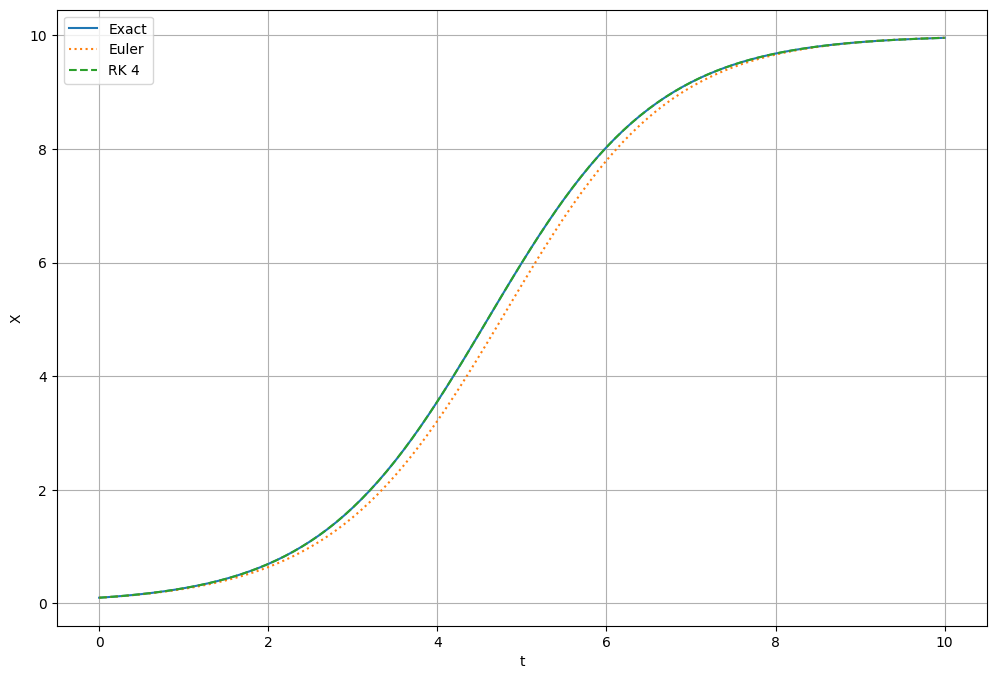

In [4]:
fig = plt.figure(figsize=(12,8))
plt.plot(t,Xexact, label = "Exact")
plt.plot(t, Xeuler, linestyle=':', label = "Euler")
plt.plot(t, Xrk, linestyle='dashed', label = "RK 4")
plt.xlabel('t')
plt.ylabel('X')
plt.legend()
plt.grid(True)

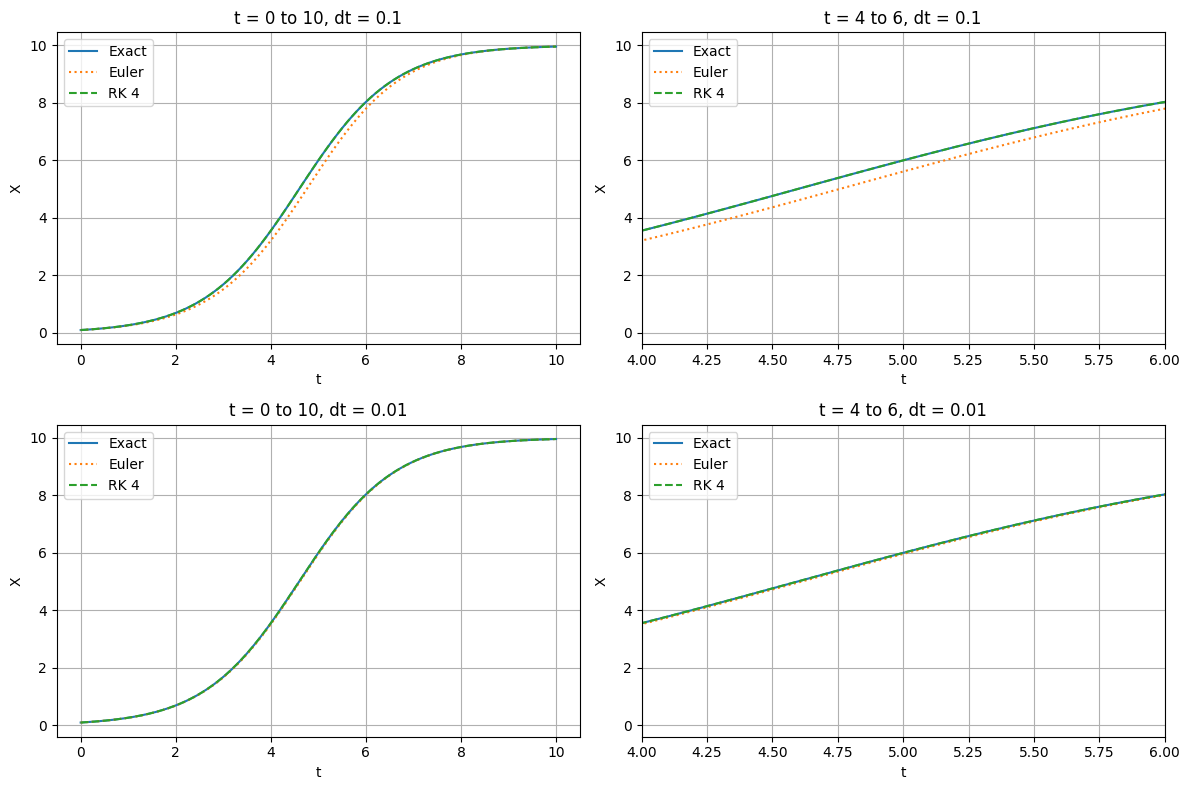

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(12,8))
ax[0, 0].title.set_text('t = 0 to 10, dt = 0.1')
ax[0, 0].plot(t, Xexact, label = "Exact")
ax[0, 0].plot(t, Xeuler , linestyle=':', label = "Euler")
ax[0, 0].plot(t, Xrk, linestyle='dashed', label = "RK 4")
ax[0, 0].set_xlabel('t')
ax[0, 0].set_ylabel('X')
ax[0, 0].legend()
ax[0, 0].grid(True)

ax[0, 1].title.set_text('t = 4 to 6, dt = 0.1')
ax[0, 1].plot(t, Xexact, label = "Exact")
ax[0, 1].plot(t, Xeuler, linestyle=':', label = "Euler")
ax[0, 1].plot(t, Xrk, linestyle='dashed', label = "RK 4")
ax[0, 1].set_xlim(4, 6)
ax[0, 1].set_xlabel('t')
ax[0, 1].set_ylabel('X')
ax[0, 1].legend()
ax[0, 1].grid(True)

#Make another solution use dt = 0.01 here

dt = 0.01
t = np.arange(0.0,10.0+dt,dt)
t, Xexact = exact(t, x_0)
t, Xeuler = euler(t, x_0)
t, Xrk = rk(t, x_0)

ax[1, 0].title.set_text('t = 0 to 10, dt = 0.01')
ax[1, 0].plot(t, Xexact, label = "Exact")
ax[1, 0].plot(t, Xeuler, linestyle=':', label = "Euler")
ax[1, 0].plot(t, Xrk, linestyle='dashed', label = "RK 4")
ax[1, 0].set_xlabel('t')
ax[1, 0].set_ylabel('X')
ax[1, 0].legend()
ax[1, 0].grid(True)

ax[1, 1].title.set_text('t = 4 to 6, dt = 0.01')
ax[1, 1].plot(t, Xexact, label = "Exact")
ax[1, 1].plot(t, Xeuler, linestyle=':', label = "Euler")
ax[1, 1].plot(t, Xrk, linestyle='dashed', label = "RK 4")
ax[1, 1].set_xlim(4, 6)
ax[1, 1].set_xlabel('t')
ax[1, 1].set_ylabel('X')
ax[1, 1].legend()
ax[1, 1].grid(True)

plt.tight_layout()

---

### Discussion

We can see that in case of `dt = 0.1` there is a noticable difference between Euler Method and Runge-Kutta Method, where Runge-Kutta method is almost exactly the same to the exact solution while Euler method is a bit far off. However, in the case of `dt = 0.01` the difference shrinks because the resolution increases..